# Import Packages

In [7]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading and Explantory Data Analysis

In [9]:
df = pd.read_csv("logs/WednesdayTraffic_cleaned.csv")
print(df.shape)
print(df.columns)
print(df.describe(include="all"))
print(df["Label"].value_counts())

numeric_df = df.select_dtypes(include="number")
corr_matrix = numeric_df.corr()

print(corr_matrix)

(1031018, 80)
Index(['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Siz

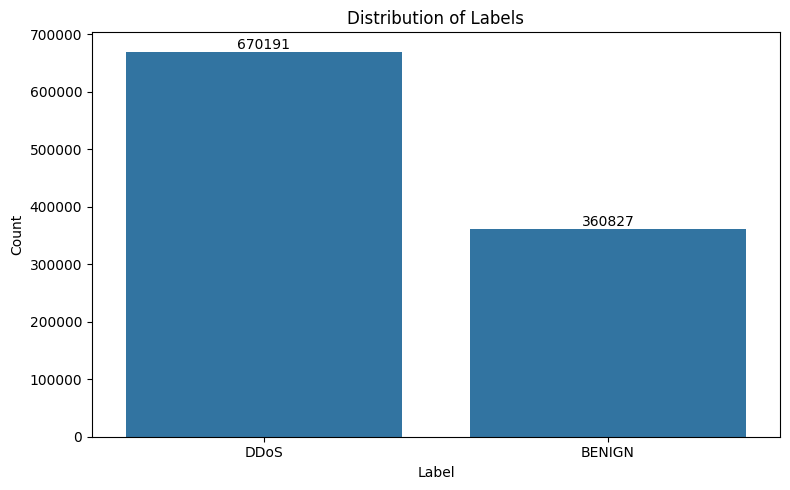

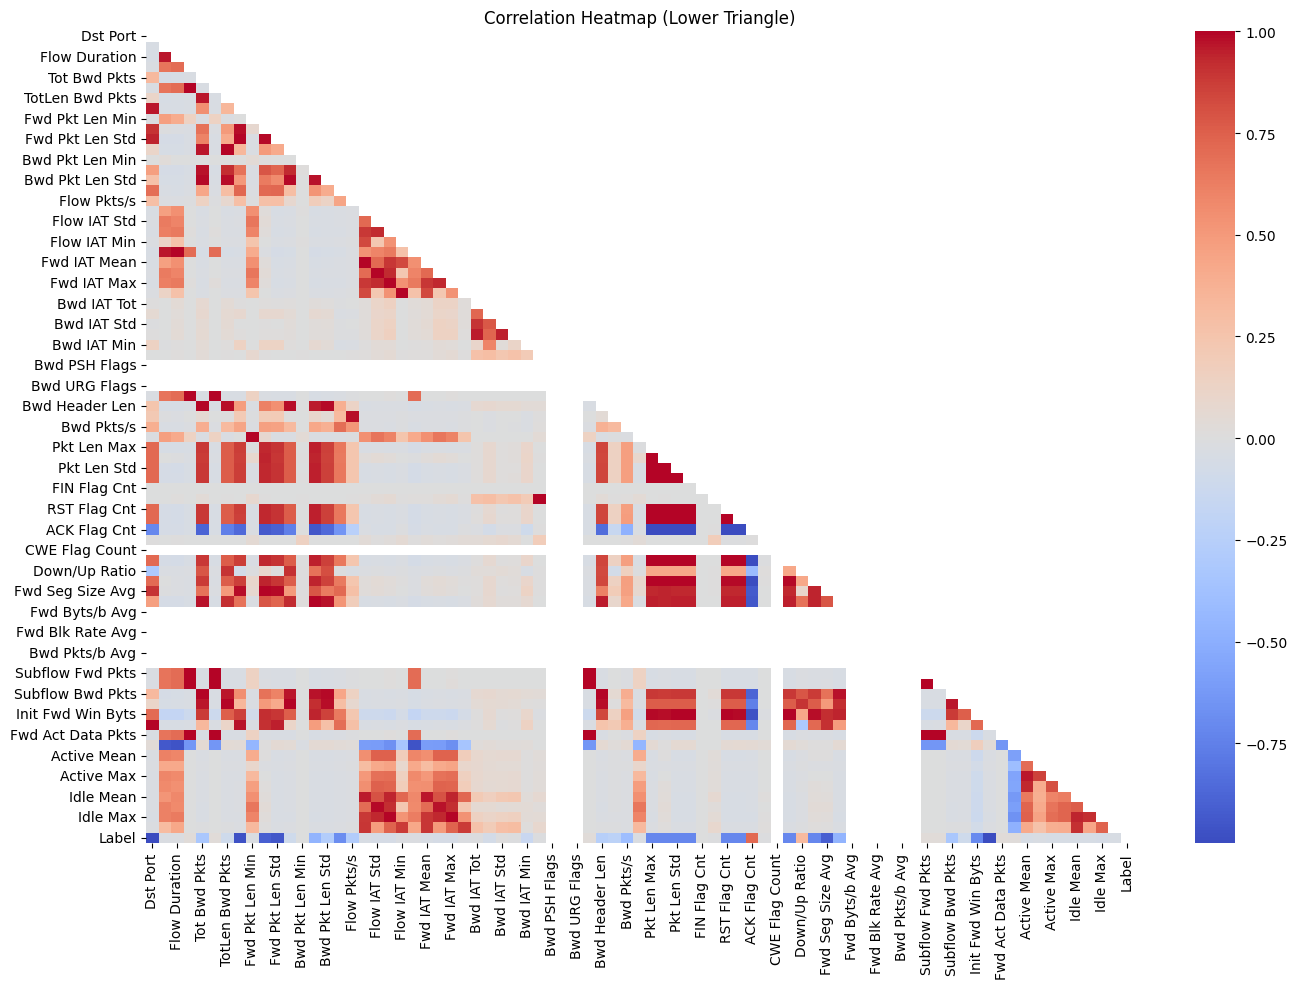

In [12]:
# Label distribution
label_counts = df["Label"].value_counts()
total = label_counts.sum()

# Map numeric labels to names
label_map = {
    0: "BENIGN",
    1: "DDoS"
}

df["Label_Name"] = df["Label"].map(label_map)

label_counts = df["Label_Name"].value_counts()

plt.figure(figsize=(8,5))
ax = sns.barplot(x=label_counts.index, y=label_counts.values)
plt.title("Distribution of Labels")
plt.xlabel("Label")
plt.ylabel("Count")

for i, v in enumerate(label_counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Select only numeric columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr_matrix = numeric_df.corr()

# Optional: mask upper triangle for cleaner view
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, mask=mask, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Lower Triangle)")
plt.tight_layout()
plt.show()